In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten
from keras.utils import pad_sequences
from tensorflow.keras.datasets import imdb
import tensorflow as tf


In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=10000)

In [ ]:
len(X_train[0])

218

In [ ]:
X_train=pad_sequences(X_train,padding='post',maxlen=100)
X_test=pad_sequences(X_test,padding='post',maxlen=100)

In [ ]:
len(X_train[434])


100

In [ ]:
model=Sequential()
model.add(Embedding(10000,16,input_length=100))
model.add(SimpleRNN(32,return_sequences=False))
model.add(Dense(1,activation='sigmoid'))

In [ ]:

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5928 - loss: 0.6597 - val_accuracy: 0.6524 - val_loss: 0.6153
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7520 - loss: 0.5092 - val_accuracy: 0.7118 - val_loss: 0.5502
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8040 - loss: 0.4307 - val_accuracy: 0.7934 - val_loss: 0.4803
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8957 - loss: 0.2678 - val_accuracy: 0.8012 - val_loss: 0.4848
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9442 - loss: 0.1635 - val_accuracy: 0.7650 - val_loss: 0.6079
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9629 - loss: 0.1199 - val_accuracy: 0.7260 - val_loss: 0.7442
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9447 - loss: 0.1328 - val_accuracy: 0.7506 - val_loss: 0.8033
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9582 - loss: 0.1044 - val_ac

In [ ]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test)
y_pred=np.where(y_pred>0.5,1,0)
accuracy_score(y_test,y_pred)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step


0.77296

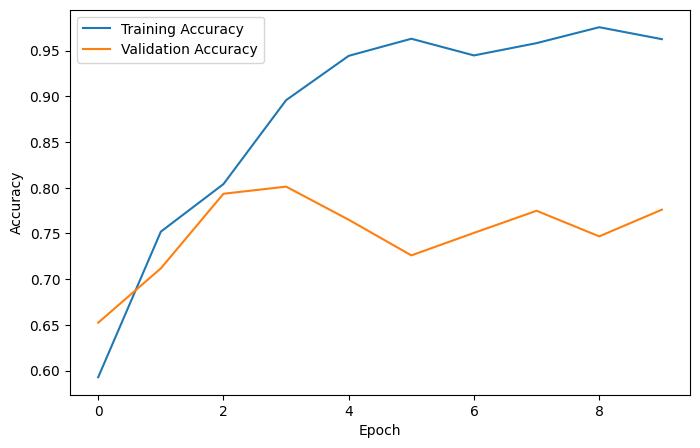

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

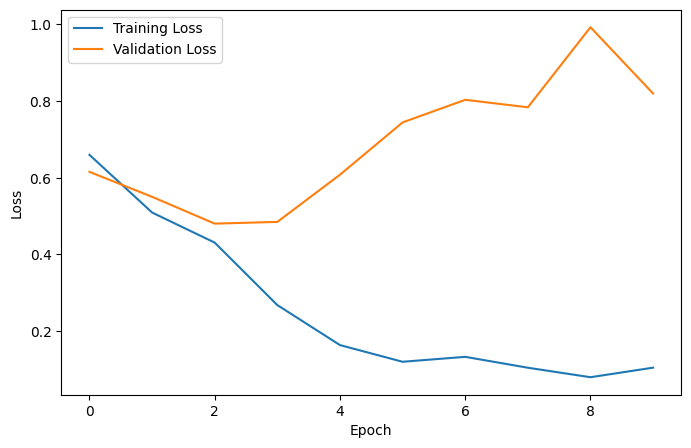

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()